In [8]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
pd.set_option('display.max_rows', 200)
warnings.filterwarnings("ignore")
begDate    = "20231001"
endData    = "20240504"
sampleDate = "20240409"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = "demo_5"

In [9]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 138/138 [00:00<00:00, 36312.04it/s]
[Parallel(n_jobs=100)]: Batch computation too fast (0.11428427696228027s.) Setting batch_size=2.
[Parallel(n_jobs=100)]: Done   9 out of 138 | elapsed:    0.3s remaining:    3.8s
[Parallel(n_jobs=100)]: Done  23 out of 138 | elapsed:    0.4s remaining:    2.2s
[Parallel(n_jobs=100)]: Done  37 out of 138 | elapsed:    0.6s remaining:    1.7s
[Parallel(n_jobs=100)]: Done  51 out of 138 | elapsed:    0.8s remaining:    1.4s
[Parallel(n_jobs=100)]: Done  65 out of 138 | elapsed:    1.0s remaining:    1.1s
[Parallel(n_jobs=100)]: Done  79 out of 138 | elapsed:    1.2s remaining:    0.9s
[Parallel(n_jobs=100)]: Done  93 out of 138 | elapsed:    1.4s remaining:    0.7s
[Parallel(n_jobs=100)]: Done 107 out of 138 | elapsed:    1.6s remaining:    0.5s
[Parallel(n_jobs=100)]: Done 121 out of 138 | elapsed:    1.7s remaining:    0.2s
[Parallel(n_jobs=100)]: Done 135 out of 138 | elapsed:    1.9s remaining:    0.0s
[Parallel(n_jobs=100)]: Done 1

In [10]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [11]:
label_df = pd.read_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet")
feature_1min_df['revtrend_add_BSratioQ'] = (feature_1min_df['revtrend_add_B_Qty'] - feature_1min_df['revtrend_add_S_Qty']) / feature_1min_df['allQrt']

In [12]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

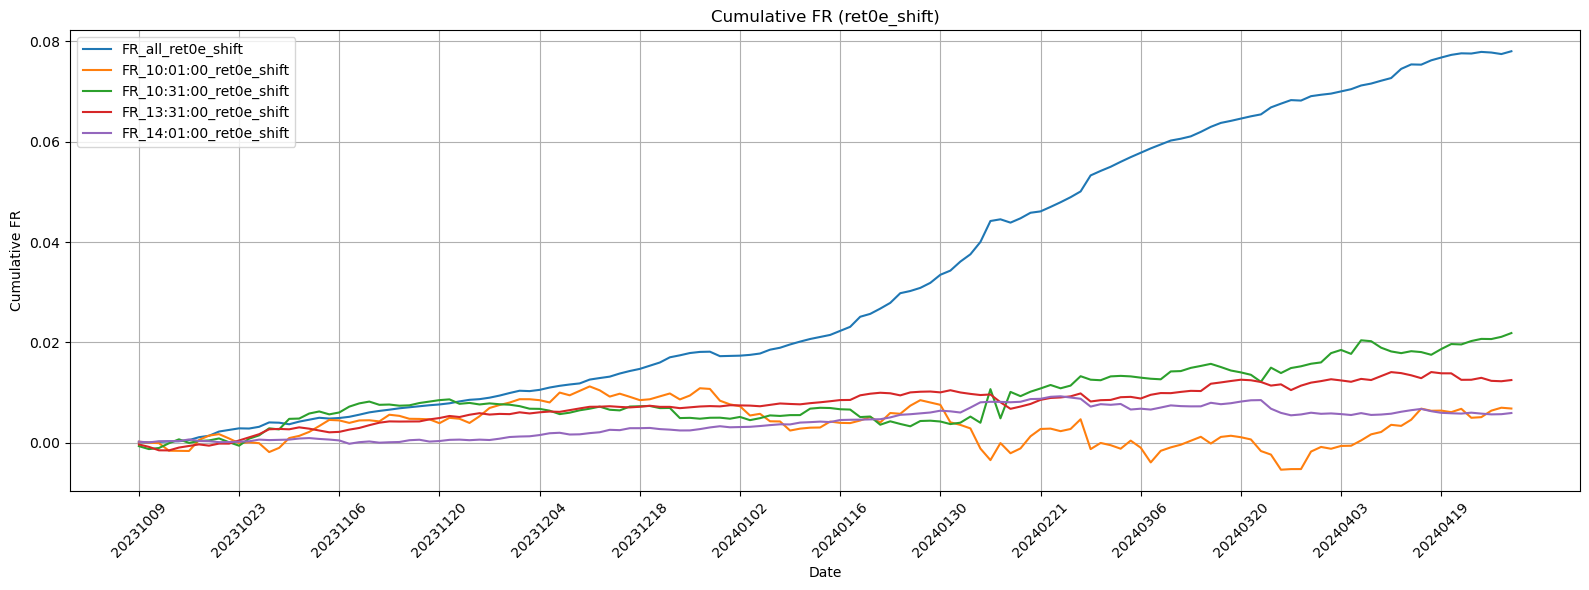

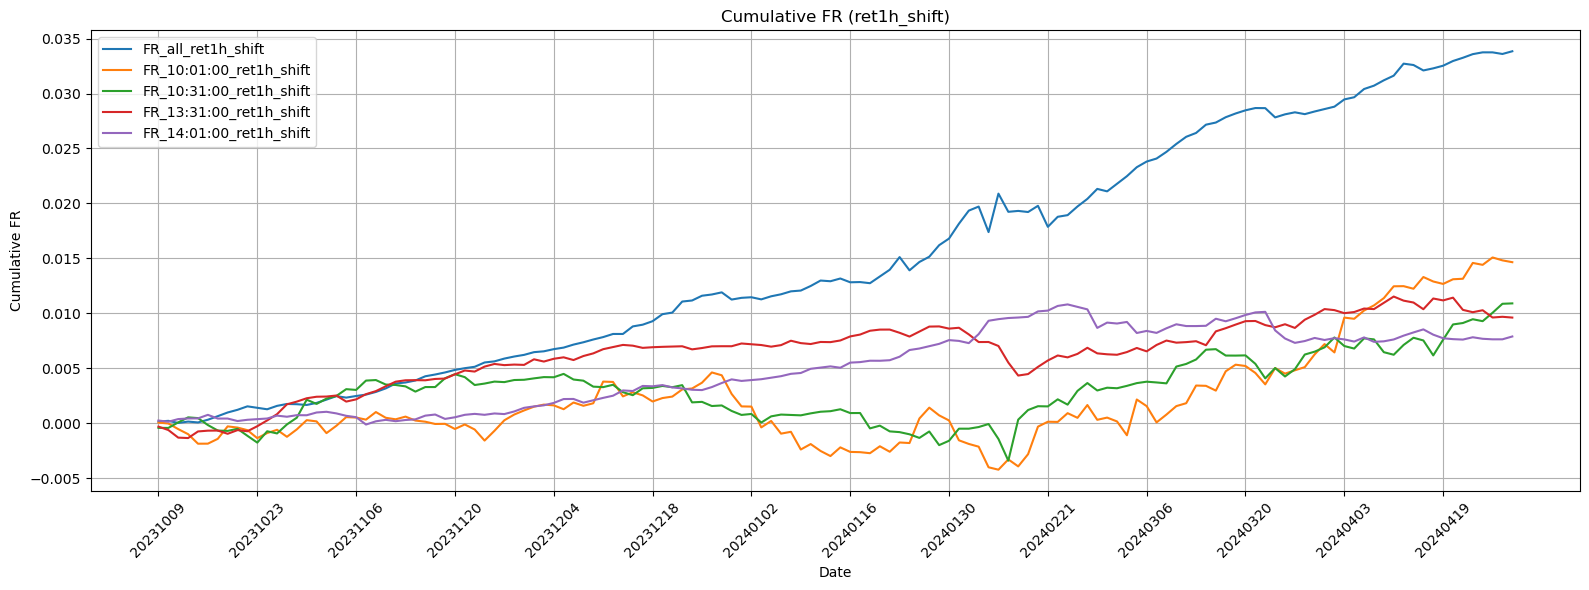

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你已经有以下变量
feat_col = 'revtrend_add_BSratioQ'
ret_cols = ['ret0e_shift', 'ret1h_shift']
time_points = ['10:01:00', '10:31:00', '13:31:00', '14:01:00']

df = feature_all_df.reset_index()

# ---------- 全部时间点 (FR_all_*) ----------
fr_all_results = {}
for ret_col in ret_cols:
    sub_df = df[[feat_col, ret_col, 'date']].dropna()

    # 按date groupby，计算 FR = cov(x, y) / std(x)
    grouped = sub_df.groupby('date')
    mean_x = grouped[feat_col].transform('mean')
    mean_y = grouped[ret_col].transform('mean')
    std_x = grouped[feat_col].transform('std')

    cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
    std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

    fr = cov_xy / std_x_daily.replace(0, np.nan)
    fr_all_results[f'FR_all_{ret_col}'] = fr

# ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
fr_time_results = {}

for tp in time_points:
    df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
    for ret_col in ret_cols:
        grouped = df_tp.groupby('date')
        x = df_tp[feat_col]
        y = df_tp[ret_col]
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
        std_x_daily = std_x.groupby(df_tp['date']).first()

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_time_results[f'FR_{tp}_{ret_col}'] = fr

# 合并所有结果
fr_all_df = pd.DataFrame(fr_all_results)
fr_time_df = pd.DataFrame(fr_time_results)
fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

# 计算 cumulative FR
cumulative_fr_df = fr_df.cumsum()


# 分别提取 ret0e 和 ret1h 的 FR 列
fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

# 画 ret0e_shift 的 Cumulative FR 图
plt.figure(figsize=(16, 6))
for col in fr_0e_cols:
    plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

plt.title('Cumulative FR (ret0e_shift)')
plt.xlabel('Date')
plt.ylabel('Cumulative FR')
plt.legend()
plt.grid(True)
plt.xticks(cumulative_fr_df.index[::10], rotation=45)
plt.tight_layout()
plt.show()

# 画 ret1h_shift 的 Cumulative FR 图
plt.figure(figsize=(16, 6))
for col in fr_1h_cols:
    plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

plt.title('Cumulative FR (ret1h_shift)')
plt.xlabel('Date')
plt.ylabel('Cumulative FR')
plt.legend()
plt.grid(True)
plt.xticks(cumulative_fr_df.index[::10], rotation=45)
plt.tight_layout()
plt.show()

fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    